# 01 — Features Part 1: Niveles institucionales + Microestructura + Indicadores clásicos

**Objetivo:** Construir el dataset de ~100 features para todos los timestamps M1 del periodo de análisis.

| Módulo | Features | Archivo |
|--------|----------|--------|
| Niveles institucionales | ~15 | `src/features/levels.py` |
| Microestructura (M5, M15, H1) | ~40 | `src/features/microstructure.py` |
| Indicadores técnicos (M15, H1, H4) | ~45 | `src/features/technical.py` |

**Regla de oro (point-in-time):** En cada timestamp T, usamos SOLO datos de barras cerradas anteriores a T.

In [1]:
# ── Celda 1: Imports y carga de OHLC ground truth ─────────────────────────────
import sys
import logging
from pathlib import Path

PROJECT_ROOT = Path('..').resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(name)s | %(levelname)s | %(message)s',
    datefmt='%H:%M:%S',
)

from v2.config.settings import DATA_GROUND_TRUTH, DATA_FEATURES

def load_gt(tf: str) -> pd.DataFrame:
    path = DATA_GROUND_TRUTH / f'ohlc_{tf}.parquet'
    if not path.exists():
        print(f'  ⚠ {tf}: archivo no encontrado ({path})')
        return pd.DataFrame()
    df = pd.read_parquet(path)
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, utc=True)
    elif df.index.tz is None:
        df.index = df.index.tz_localize('UTC')
    print(f'  {tf:5s}: {len(df):7,d} barras | {df.index.min()} → {df.index.max()}')
    return df

print('=== Cargando OHLC ground truth ===')
m1  = load_gt('M1')
m5  = load_gt('M5')
m15 = load_gt('M15')
h1  = load_gt('H1')
h4  = load_gt('H4')

print('\nCarga completada.')

=== Cargando OHLC ground truth ===
  M1   :  59,268 barras | 2026-03-01 22:00:00+00:00 → 2026-04-30 20:58:00+00:00
  M5   :  11,861 barras | 2026-03-01 22:00:00+00:00 → 2026-04-30 20:55:00+00:00
  M15  :   3,956 barras | 2026-03-01 22:00:00+00:00 → 2026-04-30 20:45:00+00:00
  H1   :     989 barras | 2026-03-01 22:00:00+00:00 → 2026-04-30 20:00:00+00:00
  H4   :     259 barras | 2026-03-01 21:00:00+00:00 → 2026-04-30 21:00:00+00:00

Carga completada.


In [2]:
# ── Celda 2: Niveles institucionales ─────────────────────────────────────────
from v2.src.features.levels import (
    compute_pdh_pdl,
    compute_weekly_levels,
    compute_monthly_levels,
    compute_asian_levels,
)

if m15.empty:
    print('⚠ No hay datos M15. Ejecuta primero el notebook 00.')
else:
    print('Calculando PDH/PDL...')
    pdh_pdl = compute_pdh_pdl(m15)

    print('Calculando niveles semanales...')
    weekly = compute_weekly_levels(m15)

    print('Calculando niveles mensuales...')
    monthly = compute_monthly_levels(m15)

    print('Calculando Asian Range...')
    asian = compute_asian_levels(m15, m5_df=m5 if not m5.empty else None)

    all_levels = pd.concat([pdh_pdl, weekly, monthly, asian], axis=1)

    print(f'\nTotal columnas de niveles: {len(all_levels.columns)}')
    print(f'Columnas: {list(all_levels.columns)}')

    # Muestra alrededor del primer trade real (2026-03-19)
    print('\n=== Muestra: 2026-03-19 (primer trade real) ===')
    sample = all_levels.loc['2026-03-19 00:00':'2026-03-19 06:00']
    display(sample[['pdh', 'pdl', 'weekly_high', 'weekly_low', 'asian_high', 'asian_low', 'asian_mid']].head(10))

Calculando PDH/PDL...
Calculando niveles semanales...
Calculando niveles mensuales...
Calculando Asian Range...

Total columnas de niveles: 15
Columnas: ['pdh', 'pdl', 'pdh_pdl_source_date', 'weekly_high', 'weekly_low', 'weekly_range_size', 'monthly_high', 'monthly_low', 'asian_high', 'asian_low', 'asian_mid', 'asian_vwap', 'asian_range_pips', 'asian_window_start_utc', 'asian_window_end_utc']

=== Muestra: 2026-03-19 (primer trade real) ===


C:\Users\lenovo\OneDrive\Escritorio\xauusd-reverse-engineering\v2\src\features\levels.py:159: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  month_start = df.index.to_series().dt.to_period("M").dt.start_time


,pdh,pdl,weekly_high,weekly_low,asian_high,asian_low,asian_mid
time_utc,,,,,,,
2026-03-19 00:00:00+00:00,4899.18,4806.93,5238.53,4967.42,NaN,NaN,NaN
2026-03-19 00:15:00+00:00,4899.18,4806.93,5238.53,4967.42,NaN,NaN,NaN
2026-03-19 00:30:00+00:00,4899.18,4806.93,5238.53,4967.42,NaN,NaN,NaN
2026-03-19 00:45:00+00:00,4899.18,4806.93,5238.53,4967.42,NaN,NaN,NaN
2026-03-19 01:00:00+00:00,4899.18,4806.93,5238.53,4967.42,NaN,NaN,NaN
2026-03-19 01:15:00+00:00,4899.18,4806.93,5238.53,4967.42,NaN,NaN,NaN
2026-03-19 01:30:00+00:00,4899.18,4806.93,5238.53,4967.42,NaN,NaN,NaN
2026-03-19 01:45:00+00:00,4899.18,4806.93,5238.53,4967.42,NaN,NaN,NaN
2026-03-19 02:00:00+00:00,4899.18,4806.93,5238.53,4967.42,4867.15,4803.48,4835.315


Calculando distancias a niveles...
Features de distancia: 22
['dist_to_pdh_pips_signed', 'dist_to_pdh_pips_abs', 'dist_to_pdl_pips_signed', 'dist_to_pdl_pips_abs', 'dist_to_weekly_high_pips_signed', 'dist_to_weekly_high_pips_abs', 'dist_to_weekly_low_pips_signed', 'dist_to_weekly_low_pips_abs', 'dist_to_monthly_high_pips_signed', 'dist_to_monthly_high_pips_abs', 'dist_to_monthly_low_pips_signed', 'dist_to_monthly_low_pips_abs', 'dist_to_asian_high_pips_signed', 'dist_to_asian_high_pips_abs', 'dist_to_asian_low_pips_signed', 'dist_to_asian_low_pips_abs', 'dist_to_asian_mid_pips_signed', 'dist_to_asian_mid_pips_abs', 'dist_to_asian_vwap_pips_signed', 'dist_to_asian_vwap_pips_abs', 'nearest_level', 'dist_to_nearest_pips']

Trades cargados: 42 total | 30 in-sample

Diagnóstico previo al merge:
  trades_for_merge - filas: 30, NaT en time_open_utc: 0
  distances_clean - filas: 3956, NaT en time_utc: 0

=== ANÁLISIS EN ENTRIES DE TRADES REALES IN-SAMPLE (n=30) ===

Nivel más cercano en el mom

C:\Users\lenovo\OneDrive\Escritorio\xauusd-reverse-engineering\v2\src\features\levels.py:330: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  result["nearest_level"] = abs_dist_df.idxmin(axis=1)


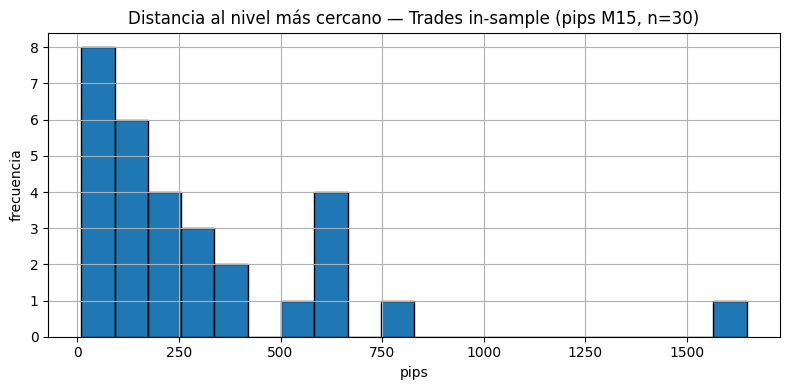


✓ Guardado trade_snapshots_levels.parquet (30 rows)


In [4]:
# ── Celda 3: Distancias a niveles + análisis de trades reales (FIX) ──────────
from v2.src.features.levels import compute_distances_to_levels

if m15.empty:
    print('⚠ No hay datos M15.')
else:
    print('Calculando distancias a niveles...')
    distances = compute_distances_to_levels(m15, all_levels)

    print(f'Features de distancia: {len(distances.columns)}')
    print(distances.columns.tolist())

    # Cargar trades reales (in-sample para descubrir la regla)
    trades_path = DATA_GROUND_TRUTH / 'trades.parquet'
    if trades_path.exists():
        trades_all = pd.read_parquet(trades_path)
        trades_all['time_open_utc'] = pd.to_datetime(trades_all['time_open_utc'], utc=True)
        trades = trades_all[trades_all['sample'] == 'in_sample'].copy()
        print(f'\nTrades cargados: {len(trades_all)} total | {len(trades)} in-sample')

        # Preparar el right-side del merge: limpiar NaT y NaN, ordenar
        distances_clean = distances.copy()
        distances_clean = distances_clean[distances_clean.index.notna()]
        distances_clean = distances_clean.sort_index()
        distances_clean = distances_clean.reset_index()
        # El índice de m15 se llama 'time_utc' o se llama algo distinto - normalizar
        if distances_clean.columns[0] != 'time_utc':
            distances_clean = distances_clean.rename(columns={distances_clean.columns[0]: 'time_utc'})

        # Preparar el left-side
        trades_for_merge = trades[['time_open_utc', 'position_id', 'type', 'price_open', 'sl_initial', 'tp_initial', 'profit']].copy()
        trades_for_merge = trades_for_merge.sort_values('time_open_utc').reset_index(drop=True)

        # Diagnóstico previo al merge
        print(f'\nDiagnóstico previo al merge:')
        print(f'  trades_for_merge - filas: {len(trades_for_merge)}, NaT en time_open_utc: {trades_for_merge["time_open_utc"].isna().sum()}')
        print(f'  distances_clean - filas: {len(distances_clean)}, NaT en time_utc: {distances_clean["time_utc"].isna().sum()}')

        # Merge_asof: para cada trade, encuentra el snapshot M15 con timestamp <= time_open_utc
        trade_snapshots = pd.merge_asof(
            trades_for_merge,
            distances_clean,
            left_on='time_open_utc',
            right_on='time_utc',
            direction='backward',
            tolerance=pd.Timedelta('30min'),
        )

        print(f'\n=== ANÁLISIS EN ENTRIES DE TRADES REALES IN-SAMPLE (n={len(trade_snapshots)}) ===')

        # nearest_level — los NaN aquí son trades donde no se encontró match (raros)
        n_no_match = trade_snapshots['nearest_level'].isna().sum()
        if n_no_match > 0:
            print(f'  ⚠ Trades sin nivel asignado: {n_no_match}')

        nearest_counts = trade_snapshots['nearest_level'].value_counts(dropna=False)
        print('\nNivel más cercano en el momento de entrada:')
        print(nearest_counts.to_string())

        valid_dist = trade_snapshots['dist_to_nearest_pips'].dropna()
        print(f'\nDistancia al nivel más cercano (pips):')
        print(f'  Media: {valid_dist.mean():.1f}')
        print(f'  Mediana: {valid_dist.median():.1f}')
        print(f'  P10: {valid_dist.quantile(0.1):.1f}')
        print(f'  P50: {valid_dist.quantile(0.5):.1f}')
        print(f'  P90: {valid_dist.quantile(0.9):.1f}')

        # Cruce nivel x dirección — esto es la pista mas potente
        print(f'\nCruce nivel × dirección del trade:')
        crosstab = pd.crosstab(trade_snapshots['nearest_level'], trade_snapshots['type'])
        print(crosstab.to_string())

        # Histograma
        fig, ax = plt.subplots(figsize=(8, 4))
        valid_dist.hist(bins=20, ax=ax, edgecolor='black')
        ax.set_title(f'Distancia al nivel más cercano — Trades in-sample (pips M15, n={len(valid_dist)})')
        ax.set_xlabel('pips')
        ax.set_ylabel('frecuencia')
        plt.tight_layout()
        plt.show()

        # Guardar para próximas celdas
        trade_snapshots.to_parquet(DATA_FEATURES / 'trade_snapshots_levels.parquet')
        print(f'\n✓ Guardado trade_snapshots_levels.parquet ({len(trade_snapshots)} rows)')
    else:
        print('⚠ trades.parquet no encontrado.')

In [5]:
print("=== CROSSTAB COMPLETO: nivel × dirección ===")
print()
crosstab = pd.crosstab(trade_snapshots['nearest_level'], trade_snapshots['type'])
print(crosstab.to_string())
print()
print("Totales por nivel:")
print((crosstab['BUY'] + crosstab['SELL']).sort_values(ascending=False).to_string())

=== CROSSTAB COMPLETO: nivel × dirección ===

type           BUY  SELL
nearest_level           
asian_high       7     0
asian_low        1     1
asian_mid        2     1
pdh              2     1
pdl              6     6
weekly_high      1     0
weekly_low       1     1

Totales por nivel:
nearest_level
pdl            12
asian_high      7
asian_mid       3
pdh             3
asian_low       2
weekly_low      2
weekly_high     1


In [6]:
# Análisis profundo de los 7 trades BUY cerca del Asian High
asian_high_buys = trade_snapshots[
    (trade_snapshots['nearest_level'] == 'asian_high') & 
    (trade_snapshots['type'] == 'BUY')
]

print(f"=== 7 BUYs cerca del Asian High ===")
print()
print(asian_high_buys[['time_open_utc', 'price_open', 'sl_initial', 'tp_initial', 
                       'dist_to_asian_high_pips_signed', 'dist_to_asian_high_pips_abs', 
                       'profit']].to_string())
print()

# Signed positivo = precio por encima del Asian High
# Signed negativo = precio por debajo del Asian High
above = (asian_high_buys['dist_to_asian_high_pips_signed'] > 0).sum()
below = (asian_high_buys['dist_to_asian_high_pips_signed'] < 0).sum()
print(f"Por encima del Asian High: {above} / 7")
print(f"Por debajo del Asian High: {below} / 7")
print()
print(f"Distancia signed media: {asian_high_buys['dist_to_asian_high_pips_signed'].mean():.1f} pips")
print(f"Distancia signed mediana: {asian_high_buys['dist_to_asian_high_pips_signed'].median():.1f} pips")

=== 7 BUYs cerca del Asian High ===

               time_open_utc  price_open  sl_initial  tp_initial  dist_to_asian_high_pips_signed  dist_to_asian_high_pips_abs  profit
8  2026-03-30 05:20:21+00:00     4512.57     4479.75     4544.18                           -93.4                         93.4   12.74
9  2026-03-30 23:44:30+00:00     4518.70     4492.32     4542.96                            36.3                         36.3  -34.59
10 2026-03-31 22:41:58+00:00     4689.85     4663.71     4720.52                           650.2                        650.2  -26.24
11 2026-03-31 22:59:29+00:00     4680.90     4658.95     4722.63                           612.4                        612.4   35.89
12 2026-04-01 22:31:17+00:00     4771.87     4752.24     4791.91                           519.8                        519.8   18.53
14 2026-04-06 02:32:37+00:00     4660.08     4659.67     4735.74                          -167.1                        167.1   39.34
24 2026-04-20 02:47:51+00

In [3]:
# Diagnóstico de qué trades.parquet está leyendo el notebook
import pandas as pd
from pathlib import Path

# Path que el código de la Celda 3 está usando (averiguar)
from v2.config.settings import DATA_GROUND_TRUTH
trades_path = DATA_GROUND_TRUTH / 'trades.parquet'
print(f"Path: {trades_path}")
print(f"Existe: {trades_path.exists()}")
print(f"Tamaño: {trades_path.stat().st_size} bytes")
print(f"Última modificación: {pd.Timestamp(trades_path.stat().st_mtime, unit='s')}")
print()

trades = pd.read_parquet(trades_path)
print(f"Shape: {trades.shape}")
print(f"Columnas: {list(trades.columns)}")
print()
print(f"NaN en time_open_utc: {trades['time_open_utc'].isna().sum()}")
print(f"NaN en sl_initial: {trades['sl_initial'].isna().sum() if 'sl_initial' in trades.columns else 'no existe'}")
print(f"NaN en sl: {trades['sl'].isna().sum() if 'sl' in trades.columns else 'no existe'}")
print()
print("Primeros 5 trades:")
print(trades.head(5).to_string())

Path: C:\Users\lenovo\OneDrive\Escritorio\xauusd-reverse-engineering\v2\data\ground_truth\trades.parquet
Existe: True
Tamaño: 14516 bytes
Última modificación: 2026-05-12 12:06:56.029340029

Shape: (42, 18)
Columnas: ['position_id', 'time_open_utc', 'time_close_utc', 'duration_minutes', 'type', 'volume', 'symbol', 'price_open', 'sl_initial', 'tp_initial', 'price_close', 'profit', 'commission', 'swap', 'close_comment', 'close_type', 'sample', 'excluded']

NaN en time_open_utc: 0
NaN en sl_initial: 0
NaN en sl: no existe

Primeros 5 trades:
   position_id             time_open_utc            time_close_utc  duration_minutes  type  volume    symbol  price_open  sl_initial  tp_initial  price_close  profit  commission  swap close_comment close_type     sample  excluded
0    413086299 2026-03-19 00:45:58+00:00 2026-03-19 01:37:28+00:00         51.500000   BUY    0.01  XAUUSD..     4838.09     4815.13     4858.20      4857.95   19.86         0.0   0.0                   manual  in_sample     Fa

In [7]:
# ── Celda 4: Features de microestructura ─────────────────────────────────────
from v2.src.features.microstructure import compute_microstructure_features

micro_dfs = {}

for tf_name, df in [('m5', m5), ('m15', m15), ('h1', h1)]:
    if df.empty:
        print(f'⚠ {tf_name}: datos vacíos, omitiendo.')
        continue
    print(f'Calculando microestructura {tf_name}...')
    micro = compute_microstructure_features(df, prefix=tf_name)
    micro_dfs[tf_name] = micro
    print(f'  {tf_name}: {micro.shape[1]} features × {len(micro):,} filas')

print(f'\nTotal features de microestructura: {sum(d.shape[1] for d in micro_dfs.values())}')

# Verificar NaN después de warmup (primeros 50 timestamps)
print('\n=== Verificación de NaN post-warmup ===')
for tf_name, micro in micro_dfs.items():
    after_warmup = micro.iloc[51:]
    float_cols = micro.select_dtypes(include=[float]).columns
    nan_counts = after_warmup[float_cols].isna().sum()
    cols_with_nan = nan_counts[nan_counts > 0]
    if len(cols_with_nan) == 0:
        print(f'  {tf_name}: ✓ Sin NaN post-warmup')
    else:
        print(f'  {tf_name}: ⚠ NaN post-warmup en {len(cols_with_nan)} columnas')
        print(cols_with_nan)

if 'm15' in micro_dfs:
    print('\n=== Muestra M15 microestructura ===')
    display(micro_dfs['m15'].iloc[60:65])

Calculando microestructura m5...
  m5: 14 features × 11,861 filas
Calculando microestructura m15...
  m15: 14 features × 3,956 filas
Calculando microestructura h1...
  h1: 14 features × 989 filas

Total features de microestructura: 42

=== Verificación de NaN post-warmup ===
  m5: ✓ Sin NaN post-warmup
  m15: ✓ Sin NaN post-warmup
  h1: ✓ Sin NaN post-warmup

=== Muestra M15 microestructura ===


,m15_atr_14,m15_atr_21,m15_atr_50,m15_realized_vol_10,m15_realized_vol_20,m15_body_pct,m15_upper_wick_pct,m15_lower_wick_pct,m15_range_expansion_5,m15_range_expansion_20,m15_consecutive_bull,m15_consecutive_bear,m15_volume_rel_20,m15_gap_pct
time_utc,,,,,,,,,,,,,,
2026-03-02 13:00:00+00:00,16.008571,14.985238,14.2256,0.001586,0.001298,0.091014,0.487327,0.421659,0.428557,0.567302,1.0,0.0,1.270314,-0.000006
2026-03-02 13:15:00+00:00,17.212143,15.539048,14.1876,0.001944,0.001512,0.586759,0.036398,0.376843,1.591431,2.164714,0.0,1.0,1.628757,0.000000
2026-03-02 13:30:00+00:00,20.671429,18.263810,15.2378,0.003091,0.002280,0.616044,0.020978,0.362978,2.839346,4.286212,0.0,2.0,1.867389,-0.000033
2026-03-02 13:45:00+00:00,23.186429,19.958571,15.8280,0.003234,0.002382,0.291771,0.174979,0.533250,1.514827,2.594000,1.0,0.0,1.850587,0.000006
2026-03-02 14:00:00+00:00,24.717143,21.015714,16.2490,0.003241,0.002427,0.453191,0.124069,0.422741,0.856026,1.504166,0.0,1.0,1.701372,0.000067


In [8]:
# ── Celda 5: Indicadores técnicos ─────────────────────────────────────────────
from v2.src.features.technical import compute_technical_indicators

tech_dfs = {}

for tf_name, df in [('m15', m15), ('h1', h1), ('h4', h4)]:
    if df.empty:
        print(f'⚠ {tf_name}: datos vacíos, omitiendo.')
        continue
    print(f'Calculando indicadores técnicos {tf_name}...')
    tech = compute_technical_indicators(df, prefix=tf_name)
    tech_dfs[tf_name] = tech
    print(f'  {tf_name}: {tech.shape[1]} features × {len(tech):,} filas')

print(f'\nTotal features técnicos: {sum(d.shape[1] for d in tech_dfs.values())}')

# Verificar warmup (EMA200 = 200 barras, ADX ~ 28 barras)
print('\n=== Verificación de NaN post-warmup (row 201+) ===')
for tf_name, tech in tech_dfs.items():
    after_warmup = tech.iloc[201:]
    float_cols = tech.select_dtypes(include=[float]).columns
    nan_counts = after_warmup[float_cols].isna().sum()
    cols_with_nan = nan_counts[nan_counts > 0]
    if len(cols_with_nan) == 0:
        print(f'  {tf_name}: ✓ Sin NaN post-warmup')
    else:
        print(f'  {tf_name}: ⚠ NaN post-warmup: {list(cols_with_nan.index)}')
        print(cols_with_nan)

if 'm15' in tech_dfs:
    print('\n=== Muestra M15 técnicos ===')
    sample_cols = ['m15_rsi_14', 'm15_macd_hist', 'm15_bb_pct_b', 'm15_ema_21', 'm15_adx_14', 'm15_stoch_k']
    display(tech_dfs['m15'][sample_cols].iloc[205:210])

Calculando indicadores técnicos m15...
  m15: 28 features × 3,956 filas
Calculando indicadores técnicos h1...
  h1: 28 features × 989 filas
Calculando indicadores técnicos h4...
  h4: 28 features × 259 filas

Total features técnicos: 84

=== Verificación de NaN post-warmup (row 201+) ===
  m15: ✓ Sin NaN post-warmup
  h1: ✓ Sin NaN post-warmup
  h4: ✓ Sin NaN post-warmup

=== Muestra M15 técnicos ===


,m15_rsi_14,m15_macd_hist,m15_bb_pct_b,m15_ema_21,m15_adx_14,m15_stoch_k
time_utc,,,,,,
2026-03-04 03:15:00+00:00,60.256716,0.887102,0.737337,5153.543172,15.090965,73.218830
2026-03-04 03:30:00+00:00,57.510861,0.279101,0.652536,5154.886520,14.367677,56.792489
2026-03-04 03:45:00+00:00,54.428170,-0.648157,0.555909,5155.508655,13.652720,42.739242
2026-03-04 04:00:00+00:00,52.196941,-1.616305,0.473161,5155.630595,12.988832,33.149931
2026-03-04 04:15:00+00:00,53.906594,-1.982564,0.497648,5156.114178,12.555093,41.206524


In [9]:
# ── Celda 6: Integración → snapshots_M1.parquet ───────────────────────────────
# Usa merge_asof para alinear todos los feature DataFrames al índice M1

if m1.empty:
    print('⚠ No hay datos M1. Usando M15 como base de snapshots.')
    base_df = m15
    snap_name = 'snapshots_M15.parquet'
else:
    base_df = m1
    snap_name = 'snapshots_M1.parquet'

print(f'Base de snapshots: {len(base_df):,} filas ({base_df.index.min()} → {base_df.index.max()})')

def align_to_base(base: pd.DataFrame, feature_df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Alinea feature_df al índice de base usando merge_asof (backward fill)."""
    if feature_df.empty:
        print(f'  ⚠ {name}: vacío, omitiendo.')
        return pd.DataFrame(index=base.index)

    left = pd.DataFrame({'_ts': base.index}).reset_index(drop=True)
    right = feature_df.reset_index(names='_ts_feat').rename(columns={'_ts_feat': '_ts_feat'})
    right = right.rename(columns={feature_df.index.name or 'index': '_ts_feat'})
    right['_ts_feat'] = feature_df.index
    right = right.drop_duplicates('_ts_feat').sort_values('_ts_feat')

    merged = pd.merge_asof(
        left.sort_values('_ts'),
        right,
        left_on='_ts',
        right_on='_ts_feat',
        direction='backward',
    ).drop(columns=['_ts_feat'])
    merged.index = base.index
    print(f'  ✓ {name}: {merged.shape[1]-1} columnas alineadas')
    return merged.drop(columns=['_ts'])

print('Alineando features al índice base...')

# Recolectar todos los feature dfs
feature_blocks = []

if not m15.empty:
    feature_blocks.append(align_to_base(base_df, all_levels, 'levels_m15'))
    feature_blocks.append(align_to_base(base_df, distances, 'distances_m15'))

for tf_name, micro in micro_dfs.items():
    feature_blocks.append(align_to_base(base_df, micro, f'micro_{tf_name}'))

for tf_name, tech in tech_dfs.items():
    feature_blocks.append(align_to_base(base_df, tech, f'tech_{tf_name}'))

# Concatenar en un solo DataFrame
feature_blocks_nonempty = [b for b in feature_blocks if not b.empty]
snapshots = pd.concat(feature_blocks_nonempty, axis=1)
snapshots = snapshots.loc[:, ~snapshots.columns.duplicated()]

print(f'\n=== SNAPSHOTS FINALES ===')
print(f'  Shape: {snapshots.shape}')
print(f'  Columnas: {snapshots.shape[1]}')
print(f'  Filas: {len(snapshots):,}')

# NaN por columna (post-warmup)
warmup_end = 200
after_warmup = snapshots.iloc[warmup_end:]
float_cols = snapshots.select_dtypes(include=[float]).columns
nan_counts = after_warmup[float_cols].isna().sum()
total_nan = nan_counts.sum()
print(f'  NaN totales post-warmup: {total_nan:,}')

top_nan = nan_counts[nan_counts > 0].sort_values(ascending=False).head(10)
if len(top_nan) > 0:
    print(f'  Columnas con más NaN:')
    print(top_nan)

# Guardar
DATA_FEATURES.mkdir(parents=True, exist_ok=True)
out_path = DATA_FEATURES / snap_name
snapshots.to_parquet(out_path)
size_mb = out_path.stat().st_size / (1024**2)
print(f'\nGuardado en {out_path} ({size_mb:.1f} MB)')

Base de snapshots: 59,268 filas (2026-03-01 22:00:00+00:00 → 2026-04-30 20:58:00+00:00)
Alineando features al índice base...
  ✓ levels_m15: 15 columnas alineadas
  ✓ distances_m15: 22 columnas alineadas
  ✓ micro_m5: 14 columnas alineadas
  ✓ micro_m15: 14 columnas alineadas
  ✓ micro_h1: 14 columnas alineadas
  ✓ tech_m15: 28 columnas alineadas
  ✓ tech_h1: 28 columnas alineadas
  ✓ tech_h4: 28 columnas alineadas

=== SNAPSHOTS FINALES ===
  Shape: (59268, 163)
  Columnas: 163
  Filas: 59,268
  NaN totales post-warmup: 506,197
  Columnas con más NaN:
h4_dist_close_to_ema_200_pips       45706
h4_ema_200                          45706
dist_to_monthly_low_pips_signed     30242
monthly_low                         30242
monthly_high                        30242
dist_to_monthly_low_pips_abs        30242
dist_to_monthly_high_pips_signed    30242
dist_to_monthly_high_pips_abs       30242
h1_ema_200                          11788
h1_dist_close_to_ema_200_pips       11788
dtype: int64

Guardad

Trades con snapshot: 42 / 42

=== TOP 10 FEATURES MÁS DISTINTIVAS EN TRADE ENTRIES ===
(mayor diferencia entre media en trade-entries vs media global)

  dist_to_asian_low_pips_signed                  global=+280.3556  trades=+716.7269  Δ=436.3713
  dist_to_asian_vwap_pips_signed                 global=-87.3535  trades=+337.7633  Δ=425.1168
  dist_to_asian_mid_pips_signed                  global=-71.8772  trades=+349.3000  Δ=421.1772
  dist_to_asian_high_pips_signed                 global=-424.1099  trades=-18.1269  Δ=405.9830
  dist_to_monthly_high_pips_signed               global=-6965.2663  trades=-7347.2533  Δ=381.9871
  dist_to_monthly_high_pips_abs                  global=+6965.2663  trades=+7347.2533  Δ=381.9871
  dist_to_monthly_low_pips_signed                global=+6234.9337  trades=+5852.9467  Δ=381.9871
  dist_to_monthly_low_pips_abs                   global=+6234.9337  trades=+5852.9467  Δ=381.9871
  dist_to_asian_low_pips_abs                     global=+587.2323  trades=+

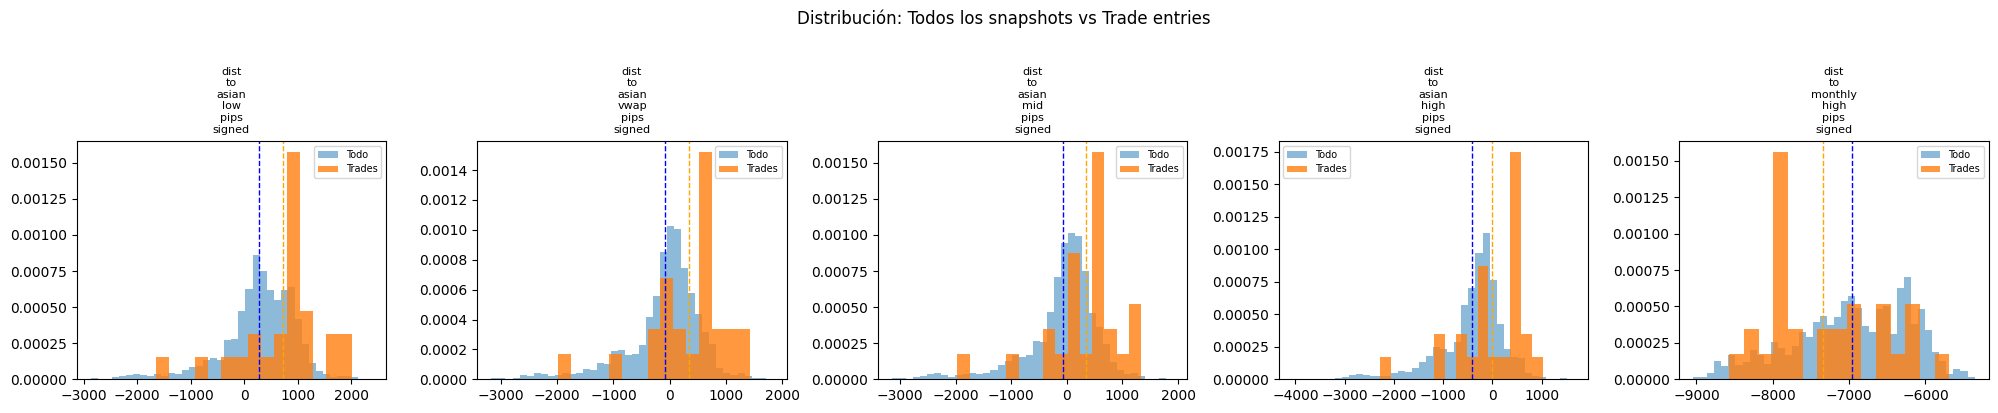


Fase 1.1 completada ✓


In [10]:
# ── Celda 7: Validación visual — features en trades vs universo ───────────────
trades_path = DATA_GROUND_TRUTH / 'trades.parquet'

if not trades_path.exists():
    print('⚠ trades.parquet no disponible. Ejecuta el notebook 00 primero.')
else:
    trades = pd.read_parquet(trades_path)
    trades['time_open_utc'] = pd.to_datetime(trades['time_open_utc'], utc=True)

    # Extraer snapshot del momento de entrada de cada trade
    snap_reset = snapshots.reset_index(names='_ts').sort_values('_ts')
    trade_snaps = pd.merge_asof(
        trades[['time_open_utc']].sort_values('time_open_utc'),
        snap_reset,
        left_on='time_open_utc',
        right_on='_ts',
        direction='backward',
    ).drop(columns=['_ts'])

    print(f'Trades con snapshot: {len(trade_snaps)} / {len(trades)}')

    # Estadísticas: media en trade-entries vs media global
    float_cols = snapshots.select_dtypes(include=[float]).columns.tolist()
    # Excluir columnas de precios absolutos (EMA, BB, etc.) — nos interesan los ratios/percentuales
    ratio_cols = [c for c in float_cols if any(x in c for x in [
        'rsi', 'adx', 'stoch', 'pct', 'rel', 'dist', 'macd_hist', 'atr',
        'body', 'wick', 'expansion', 'consecutive', 'gap', 'vol_'
    ])]

    global_means = snapshots[ratio_cols].mean()
    trade_means = trade_snaps[ratio_cols].mean()

    diff = (trade_means - global_means).abs().sort_values(ascending=False)

    print('\n=== TOP 10 FEATURES MÁS DISTINTIVAS EN TRADE ENTRIES ===')
    print('(mayor diferencia entre media en trade-entries vs media global)\n')
    top10 = diff.head(10)
    for feat, delta in top10.items():
        gm = global_means.get(feat, float('nan'))
        tm = trade_means.get(feat, float('nan'))
        print(f'  {feat:<45s}  global={gm:+.4f}  trades={tm:+.4f}  Δ={delta:.4f}')

    # Plot top 5
    top5_feats = list(top10.index[:5])
    if top5_feats:
        fig, axes = plt.subplots(1, len(top5_feats), figsize=(4 * len(top5_feats), 4))
        for ax, feat in zip(axes, top5_feats):
            vals_all = snapshots[feat].dropna()
            vals_trades = trade_snaps[feat].dropna()
            ax.hist(vals_all, bins=40, alpha=0.5, label='Todo', density=True)
            ax.hist(vals_trades, bins=15, alpha=0.8, label='Trades', density=True)
            ax.axvline(vals_all.mean(), color='blue', linestyle='--', linewidth=1)
            ax.axvline(vals_trades.mean(), color='orange', linestyle='--', linewidth=1)
            ax.set_title(feat.replace('m15_', '').replace('_', '\n'), fontsize=8)
            ax.legend(fontsize=7)
        plt.suptitle('Distribución: Todos los snapshots vs Trade entries', y=1.02)
        plt.tight_layout()
        plt.show()

    print('\nFase 1.1 completada ✓')

In [11]:
# TOP 30 features distintivas con z-score normalizado
import pandas as pd
from v2.config.settings import DATA_FEATURES, DATA_GROUND_TRUTH

# Cargar snapshots M1 (universo) y trades in-sample
snapshots_m1 = pd.read_parquet(DATA_FEATURES / 'snapshots_M1.parquet')
print(f"Snapshots M1: {len(snapshots_m1):,} filas, {len(snapshots_m1.columns)} features")

trades = pd.read_parquet(DATA_GROUND_TRUTH / 'trades.parquet')
trades_in = trades[trades['sample'] == 'in_sample'].copy()
trades_in['time_open_utc'] = pd.to_datetime(trades_in['time_open_utc'], utc=True)

# Asegurar que snapshots_m1 tenga su index ordenado
snapshots_m1 = snapshots_m1.sort_index()

# Para cada trade, encontrar el snapshot M1 inmediatamente anterior
trade_snapshots = []
for _, row in trades_in.iterrows():
    t = row['time_open_utc']
    # Buscar el snapshot más cercano (anterior o igual)
    idx = snapshots_m1.index.searchsorted(t, side='right') - 1
    if 0 <= idx < len(snapshots_m1):
        snap = snapshots_m1.iloc[idx].copy()
        snap['time_open_utc'] = t
        snap['type'] = row['type']
        trade_snapshots.append(snap)

trade_snapshots_df = pd.DataFrame(trade_snapshots)
print(f"Trade snapshots construidos: {len(trade_snapshots_df)}")

# Solo numéricas
numeric_cols = snapshots_m1.select_dtypes(include='number').columns

# Computar z-scores
results = []
for col in numeric_cols:
    if col not in trade_snapshots_df.columns:
        continue
    global_vals = snapshots_m1[col].dropna()
    trade_vals = trade_snapshots_df[col].dropna()
    if len(global_vals) == 0 or len(trade_vals) == 0:
        continue
    g_mean = global_vals.mean()
    g_std = global_vals.std()
    t_mean = trade_vals.mean()
    if g_std == 0 or pd.isna(g_std):
        continue
    z = (t_mean - g_mean) / g_std
    results.append({
        'feature': col,
        'global_mean': g_mean,
        'trade_mean': t_mean,
        'global_std': g_std,
        'abs_diff': abs(t_mean - g_mean),
        'z_score': z,
    })

results_df = pd.DataFrame(results)

print("\n=== TOP 30 FEATURES POR |Z-SCORE| (normalizado, comparable entre features) ===")
top30 = results_df.reindex(results_df['z_score'].abs().sort_values(ascending=False).index).head(30)
print(top30.to_string(index=False, float_format=lambda x: f'{x:+8.3f}'))

# Categorización
print("\n=== CONTEO POR CATEGORÍA DE FEATURE (TOP 30) ===")
def category(name):
    if 'asian' in name: return 'asian_range'
    if 'pdh' in name or 'pdl' in name: return 'pdh_pdl'
    if 'weekly' in name: return 'weekly'
    if 'monthly' in name: return 'monthly'
    if 'rsi' in name: return 'rsi'
    if 'macd' in name: return 'macd'
    if 'bb_' in name or 'bollinger' in name: return 'bollinger'
    if 'ema' in name: return 'ema'
    if 'atr' in name: return 'atr'
    if 'stoch' in name: return 'stochastic'
    if 'adx' in name: return 'adx'
    if 'consecutive' in name or 'body' in name or 'wick' in name: return 'candle_micro'
    if 'volume' in name: return 'volume'
    if 'realized_vol' in name: return 'volatility'
    if 'range' in name: return 'range'
    return 'other'

top30['category'] = top30['feature'].apply(category)
print(top30['category'].value_counts().to_string())

Snapshots M1: 59,268 filas, 163 features
Trade snapshots construidos: 30

=== TOP 30 FEATURES POR |Z-SCORE| (normalizado, comparable entre features) ===
                      feature  global_mean  trade_mean  global_std  abs_diff  z_score
                 monthly_high    +5418.850   +5418.850      +0.000    +0.000   +2.000
                  monthly_low    +4098.830   +4098.830      +0.000    +0.000   -1.000
   dist_to_asian_low_pips_abs     +587.232   +1022.741    +453.122  +435.509   +0.961
        m5_range_expansion_20       +1.028      +1.552      +0.594    +0.525   +0.883
         m5_range_expansion_5       +1.048      +1.520      +0.579    +0.473   +0.817
                    asian_low    +4773.911   +4583.444    +257.437  +190.468   -0.740
                   asian_vwap    +4810.682   +4628.763    +251.776  +181.919   -0.723
                    asian_mid    +4809.135   +4628.507    +252.530  +180.627   -0.715
             h1_volume_rel_20       +1.015      +0.729      +0.407    +0.

In [12]:
# Análisis SEPARADO BUY vs SELL para identificar la dimensión direccional
import pandas as pd

# Reusa trade_snapshots_df del análisis anterior (ya está construido)
buys  = trade_snapshots_df[trade_snapshots_df['type'] == 'BUY']
sells = trade_snapshots_df[trade_snapshots_df['type'] == 'SELL']

print(f"BUYs in-sample: {len(buys)}")
print(f"SELLs in-sample: {len(sells)}")
print()

# Para cada feature numérica, comparar media BUY vs media SELL
numeric_cols = snapshots_m1.select_dtypes(include='number').columns
diffs = []
for col in numeric_cols:
    if col not in trade_snapshots_df.columns:
        continue
    buy_vals  = buys[col].dropna()
    sell_vals = sells[col].dropna()
    if len(buy_vals) < 3 or len(sell_vals) < 3:
        continue
    g_std = snapshots_m1[col].std()
    if g_std == 0 or pd.isna(g_std):
        continue
    buy_mean = buy_vals.mean()
    sell_mean = sell_vals.mean()
    # Cuánta diferencia hay entre BUY y SELL, en unidades de std del feature
    z_diff = (buy_mean - sell_mean) / g_std
    diffs.append({
        'feature': col,
        'buy_mean': buy_mean,
        'sell_mean': sell_mean,
        'diff_buy_minus_sell': buy_mean - sell_mean,
        'z_diff': z_diff,
    })

direction_df = pd.DataFrame(diffs)
print("=== TOP 25 FEATURES QUE MÁS DIFERENCIAN BUY DE SELL ===")
print("(z_diff positivo = feature mayor en BUYs; negativo = mayor en SELLs)")
print()
top = direction_df.reindex(direction_df['z_diff'].abs().sort_values(ascending=False).index).head(25)
print(top.to_string(index=False, float_format=lambda x: f'{x:+8.3f}'))

BUYs in-sample: 20
SELLs in-sample: 10

=== TOP 25 FEATURES QUE MÁS DIFERENCIAN BUY DE SELL ===
(z_diff positivo = feature mayor en BUYs; negativo = mayor en SELLs)

                       feature  buy_mean  sell_mean  diff_buy_minus_sell   z_diff
                    h1_gap_pct    +0.000     -0.001               +0.001   +2.173
 dist_to_asian_low_pips_signed  +959.271   -414.733            +1374.005   +2.001
dist_to_asian_vwap_pips_signed  +473.273   -714.841            +1188.115   +1.803
 dist_to_asian_mid_pips_signed  +467.164   -671.850            +1139.014   +1.779
                  m15_bb_pct_b    +0.683     +0.104               +0.579   +1.726
                   m15_stoch_k   +72.477    +26.422              +46.055   +1.647
           m5_consecutive_bull    +2.300     +0.300               +2.000   +1.543
      m15_macd_hist_increasing    +0.900     +0.200               +0.700   +1.401
                    m15_rsi_14   +54.496    +38.495              +16.000   +1.371
dist_to_asian_